# Package Import 

In [1]:
# Common
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Data 
from tqdm import tqdm                                #Visualize Running Process (Lading bar)
from glob import glob
import tensorflow.image as tfi
from tensorflow.keras.utils import load_img, img_to_array      #Matrix transfromation for the image

# Data Visulization
import matplotlib.pyplot as plt

#Model Layers
from keras.models import Model                        # Define the overall Keras model using functional API
from keras.layers import Layer                        # Base class for creating custom layers
from keras.layers import Input                        # Define input tensor for functional API models
from keras.layers import Conv2D                       # 2D convolution layer to extract spatial features
from keras.layers import Concatenate                  # Concatenate multiple tensors along a specified axis
from keras.layers import UpSampling2D                 # Upsample feature maps (increase height and width)
from keras.layers import AveragePooling2D             # Downsample feature maps by averaging over pooling windows
from keras.layers import BatchNormalization           # Normalize activations to stabilize and speed up training
from keras.layers import LeakyReLU, ReLU              # LeakyReLU: allows small gradient for negatives, ReLU: standard activation
from keras.models import Sequential                  # Simple linear stack of layers for building models quickly

# Backbone
from tensorflow.keras.applications import ResNet50    

# Model Architecture Visualization
from tensorflow.keras.utils import plot_model

# Optimizer
from tensorflow.keras.optimizers import Adam

# Callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

# Model Layer Visualization
# from tf_explain.core.grad_cam import GradCAM

# Images-Mask meatadata make
You only run this cell once, remember to uncomment before run it

In [2]:

# # Path to your training dataset
# train_folder = r"D:\WORK\Python\USTH\deep_learning\data_2\train"

# def create_train_metadata(folder_path):
#     """
#     Go through the training folder, find all PNG images, 
#     and pair them with masks (same filename, assumed in 'labels' subfolder)
#     Returns a DataFrame with 'image' and 'mask' columns.
#     """
#     images = []
#     masks = []

#     images_dir = os.path.join(folder_path, "images")  # adjust if images are directly in train_folder
#     masks_dir = os.path.join(folder_path, "labels")  # adjust if masks folder has a different name

#     for filename in os.listdir(images_dir):
#         if filename.endswith(".png"):
#             image_path = os.path.join(images_dir, filename)
#             mask_path = os.path.join(masks_dir, filename)  # same filename
#             if os.path.exists(mask_path):
#                 images.append(image_path)
#                 masks.append(mask_path)
#             else:
#                 print(f"Warning: Mask not found for {filename}")

#     df = pd.DataFrame({"image": images, "mask": masks})
#     return df

# # Create training metadata
# train_df = create_train_metadata(train_folder)

# # Optional: save to CSV for future use
# train_df.to_csv("train_metadata.csv", index=False)

# print(f"Training metadata created with {len(train_df)} image-mask pairs.")

# **Data Loading**

In order to work on the model, first we need to load our data.

In [3]:
# Specify paths
root_path = r"D:\WORK\Python\USTH\deep_learning\data"
image_path = r"D:\WORK\Python\USTH\deep_learning\data\Image"
mask_path = r"D:\WORK\Python\USTH\deep_learning\data\Mask"
metadata_path = r"D:\WORK\Python\USTH\deep_learning\data\metadata.csv"

Let's have a look at the **metadata.

In [4]:
# Load file
metadata = pd.read_csv(metadata_path)

# Show
metadata

,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png
...,...,...
285,1083.jpg,1083.png
286,1084.jpg,1084.png
287,1085.jpg,1085.png
288,1086.jpg,1086.png


In [5]:
# This is a helper function
def load_image(path:str, SIZE:tuple = (256, 256), mask:bool = False):
    
    image = load_img(path)                  #load Image
    image = img_to_array(image)             # Convert to an array
    image = tfi.resize(image, SIZE)         # Resize the image
    image = tf.cast(image, tf.float32)      # Convert to Tensor of 32Bit - Float 
    image = image/255.                      # Normalize the image
    
    # Mask
    if mask:
        image = image[:, :, :1]             # If the image is a mask (segmentation ground truth), only the first channel is kept.
        
    # return image
    return image

## Load dataset

In [6]:
def prepare_dataset(dataset_path: str):

    # Set directories for images and masks
    img_folder  =   os.path.join(dataset_path, "Image")
    lbl_folder  =   os.path.join(dataset_path, "Mask")

    # Gather all image files
    img_files   =   sorted(glob(os.path.join(img_folder, "*.jpg")))

    # Create corresponding mask file list
    lbl_files   =   [os.path.join(lbl_folder, os.path.splitext(os.path.basename(f))[0] + ".png") for f in img_files]

    # Initialize arrays for storage
    total       =   len(img_files)
    imgs        =   np.zeros((total, 256, 256, 3), dtype=np.float32)
    lbls        =   np.zeros((total, 256, 256, 1), dtype=np.float32)

    # Iterate and load image-mask pairs
    for idx, (img_fp, lbl_fp) in enumerate(
        tqdm(zip(img_files, lbl_files), total=total, desc="Preparing dataset")
    ):
        img     = load_image(path=img_fp, mask=False)
        lbl     = load_image(path=lbl_fp, mask=True)

        imgs[idx] = img
        lbls[idx] = lbl

    return imgs, lbls
all_images, all_masks = prepare_dataset(root_path)

Preparing dataset: 100%|██████████| 290/290 [00:20<00:00, 14.27it/s]


# **Data Visualization**

In [ ]:
def show_images(images, masks, n_images=5, SIZE=(20,5), alpha=0.5):
    """
    Display multiple images with their corresponding masks and overlays in a single figure.

    Parameters
    ----------
    images   : np.ndarray
        Array of images with shape (N, H, W, 3)
    masks    : np.ndarray
        Array of masks with shape (N, H, W, 1) or (N, H, W)
    n_images : int
        Number of images to display
    SIZE     : tuple
        Figure size
    alpha    : float
        Transparency for overlay
    """
    
    if len(images) == 0 or len(masks) == 0:
        print("No images or masks to display.")
        return
    
    n_images = min(n_images, len(images))
    plt.figure(figsize=SIZE)
    
    for i in range(n_images):
        idx = np.random.randint(len(images))
        img = images[idx]
        mask = np.squeeze(masks[idx])
        mask_norm = mask / mask.max() if mask.max() > 0 else mask
        
        # Plot Image
        plt.subplot(3, n_images, i+1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis('off')
        
        # Plot Mask
        plt.subplot(3, n_images, i+1 + n_images)
        plt.imshow(mask_norm, cmap='gray')
        plt.title("Mask")
        plt.axis('off')
        
      
    
    plt.tight_layout()
    plt.show()


# Model Buidling

In [ ]:
class ConvBlock(Layer):
    """
    ConvBlock = Conv2D -> BatchNormalization -> ReLU.
    Encapsulates this sequence as a single custom layer.
    """

    def __init__(self, filters: int = 256, kernel_size: int = 3, dilation_rate: int = 1, **kwargs):   #Initialize the block and define its internal layers
        super().__init__(**kwargs)
        
        # Save parameters for serialization
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        
        # Define the sequential block
        self.net = Sequential([
            Conv2D(filters,
                   kernel_size=kernel_size,         #Kernel size = 3
                   padding='same',                  #Same output padding = 1
                   strides=1,                       
                   dilation_rate=dilation_rate, 
                   activation=None, 
                   use_bias=False),
            BatchNormalization(),                   #Normalization
            ReLU()                                  #Activate function
        ])
    
    def call(self, inputs, **kwargs):
        # Apply Conv2D -> Batch.N -> ReLU
        return self.net(inputs, **kwargs)
    
    def get_config(self):
        # Needed for serialization (save/load model)
        base_config = super().get_config()
        return {
            **base_config,
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate
        }


One of the **main prposal of DeepLabV3+** was the **Astrous Spatial Pyramid Pooling Layer**. Let's define this layer,

In [ ]:
def AtrousSpatialPyramidPooling(X, filters=256):
    """
    ASPP (Atrous Spatial Pyramid Pooling) - 5 Parallel Convolution Branches

Input: X (feature map from backbone)

Structure:

           ┌───────────────┐
           │       X       │
           └───────┬───────┘
                   │
   ┌───────────────┼─────────────────┐
   │               │                 │
┌───────┐       ┌───────┐         ┌───────┐
│Conv 1x1│      │Conv 3x3│       │Conv 3x3│
│dil=1   │      │dil=3   │       │dil=6   │
└───────┘       └───────┘         └───────┘
                   │                 │
             ┌─────┴─────┐       ┌─────┴─────┐
             │ Conv 3x3  │       │ Conv 3x3  │
             │ dil=12    │       │ dil=18    │
             └───────────┘       └───────────┘

All 5 branches are applied in parallel to the input X,
then typically concatenated afterwards to capture multi-scale context."""
    
    # Shape
    _, H, W, C = X.shape
    
    # --- Image Pooling branch ---
    
    #Input: X(H, W, C) --> ool size equal to the entire spatial dimension (H, W) 
    #Reduces each feature map to a single value → effectively computes the global average
    # Output shape: (1, 1, C)
    image_pool = AveragePooling2D(pool_size=(H, W), name="ASPP-ImagePool-AP")(X)        
    
               
    # Using a 1×1 kernel keeps spatial resolution (still 1×1) but:   ---> Output shape remains (1, 1, filters)        
    image_pool = ConvBlock(filters=filters, kernel_size=1, name="ASPP-ImagePool-CB")(image_pool) 
    
    
    
    #Resize the global feature map back to the same spatial size as the original feature map X.
    #Upsamples it by a factor of (H, W) (computed dynamically).
    image_pool = UpSampling2D(
        size=(H // image_pool.shape[1],
              W // image_pool.shape[2]),
        interpolation='bilinear',
        name="ASPP-ImagePool-US"
    )(image_pool)
    
    
    
    # ASPP 5 stacks [1, 3, 6, 12, 18]
    conv_1  = ConvBlock(filters=filters, kernel_size=1, dilation_rate=1,  name="ASPP-Conv1")(X)
    conv_3  = ConvBlock(filters=filters, kernel_size=3, dilation_rate=2,  name="ASPP-Conv3")(X)
    conv_6  = ConvBlock(filters=filters, kernel_size=3, dilation_rate=6,  name="ASPP-Conv6")(X)
    conv_12 = ConvBlock(filters=filters, kernel_size=3, dilation_rate=12, name="ASPP-Conv12")(X)
    conv_18 = ConvBlock(filters=filters, kernel_size=3, dilation_rate=18, name="ASPP-Conv18")(X)
    
    
    
    # --- Combine all branches ---
    combined = Concatenate(name="ASPP-Concatenate")([image_pool, conv_1, conv_3, conv_6, conv_12, conv_18])
    output = ConvBlock(filters=filters, kernel_size=1, name="ASPP-Out")(combined)
    
    return output


We have the **Sub-Layers** ready. It's time to combine them all and make the **DeepLabV3+ Encoder-Decoder model**.

In [ ]:
IMAGE_SIZE  = 256
MODEL_NAME  = "DeepLab-Custom-5ASPP"

# Input
# Shape: (256, 256, 3)
inputs      =   Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="InputLayer")

# Backbone using Resnet 
# weights='imagenet' → uses pretrained weights from ImageNet (helps faster convergence).
backbone    =   ResNet50(input_tensor=inputs, weights='imagenet', include_top=False)


# High-Level Features
# Accesses an intermediate layer output from ResNet50:
# 'conv4_block6_2_relu' corresponds to the last activation of stage 4 in ResNet/
# This layer has a stride of 16 relative to the input (i.e., output size = 1/16 of input)
DCNN =  backbone.get_layer('conv4_block6_2_relu').output                                                                      
ASPP = AtrousSpatialPyramidPooling(DCNN, filters=256)  # fixed call     




#The purpose is to resize the ASPP output to a higher spatial resolution 
# so it can align with shallower (low-level) features or the final decoder layers.                                
ASPP        =   UpSampling2D(
                size=(IMAGE_SIZE // 4 // ASPP.shape[1], 
                    IMAGE_SIZE // 4 // ASPP.shape[2]),
                    interpolation='bilinear',
                    name="ASPP-UpSample-Out"
                            )(ASPP)

# ┌─────────────┐
# │ Backbone CNN│
# │ conv4_block6│
# │ _2_relu     │
# └─────┬───────┘
#       │ Output feature map from deep CNN block
# ┌───────────────────────────────┐
# │ Atrous Spatial Pyramid Pooling │
# │ - Uses multiple dilation rates │
# │ - Captures multi-scale context │
# │ - Output filters=256           │
# └──────────────┬────────────────┘
#                │ ASPP feature map
# ┌────────────────────┐
# │ Upsampling Layer   │
# │ - Bilinear resize  │
# │ - Output size = IMAGE_SIZE/4 │
# └───────────┬────────┘
#             │ Upsampled ASPP feature map ready for decoder/concatenation

Let's have a look at the model architecture,

In [42]:
# Low-Level Features for edges extraction
LLF = backbone.get_layer('conv2_block3_2_relu').output
LLF = ConvBlock(filters=48, kernel_size=1, name="LLF-ConvBlock")(LLF)



# Combine Low & High Features for final scaled image
concat = Concatenate(axis=-1, name="Concat-LLF-HLF")([LLF, ASPP])
y = ConvBlock(filters=256, name="TopConvBlock1")(concat)
y = ConvBlock(filters=256, name="TopConvBlock2")(y)


'''
LF (Conv2 Block)               ASPP (Upsampled)
          ┌──────────────┐                  ┌───────────────┐
          │ Conv2_block3 │                  │ ASPP Upsample │
          │ _2_relu      │                  │               │
          └─────┬────────┘                  └─────┬─────────┘
                │                                  │
          ┌─────▼────────┐                         │
          │ ConvBlock 48 │                         │
          └─────┬────────┘                         │
                │                                  │
                └───────────┐                      │
                            ▼
                   ┌─────────────────┐
                   │ Concatenate     │  <- Fuse LLF + ASPP
                   └─────┬───────────┘
                         │
                 ┌───────▼─────────┐
                 │ ConvBlock 256    │
                 └───────┬─────────┘
                         │
                 ┌───────▼─────────┐
                 │ ConvBlock 256    │
                 └─────────────────┘

'''

'\nLF (Conv2 Block)               ASPP (Upsampled)\n          ┌──────────────┐                  ┌───────────────┐\n          │ Conv2_block3 │                  │ ASPP Upsample │\n          │ _2_relu      │                  │               │\n          └─────┬────────┘                  └─────┬─────────┘\n                │                                  │\n          ┌─────▼────────┐                         │\n          │ ConvBlock 48 │                         │\n          └─────┬────────┘                         │\n                │                                  │\n                └───────────┐                      │\n                            ▼\n                   ┌─────────────────┐\n                   │ Concatenate     │  <- Fuse LLF + ASPP\n                   └─────┬───────────┘\n                         │\n                 ┌───────▼─────────┐\n                 │ ConvBlock 256    │\n                 └───────┬─────────┘\n                         │\n                 ┌───────▼────

In [ ]:
# --- Upsample feature map back to original image size ---
y = UpSampling2D(
    size=(IMAGE_SIZE // y.shape[1], IMAGE_SIZE // y.shape[2]),  # Scale factor to reach input resolution
    interpolation='bilinear',                                   # Smooth interpolation for segmentation
    name="Feature-UpSample"                                     # Layer name for clarity
)(y)




# --- Final segmentation output layer ---
output = Conv2D(
    filters=1,                 # One output channel → binary segmentation
    kernel_size=3,             # 3x3 convolution for spatial refinement
    padding='same',            # Preserve spatial dimensions
    activation='sigmoid',      # Output pixel-wise probability [0, 1]
    use_bias=False,            # Bias not needed due to normalization
    name="OutputLayer"         # Name for model summary clarity
)(y)


# --- Define the complete DeepLabV3 model ---
DeepLabV3 = Model(
    inputs,                    # Input tensor (image)
    output,                    # Final segmentation map
    name=MODEL_NAME            # Model name, e.g., "DeepLab-Custom-5ASPP"
)


In [8]:
DeepLabV3.summary()

NameError: name 'DeepLabV3' is not defined

# Visualize Images

In [45]:
def show_model_preds(images, masks, model, SIZE:tuple = (15,8)) -> None:
    # Collect Image and Mask
    id = np.random.randint(len(images))
    image, mask = images[id], masks[id]
    
    # Make Prediction 
    pred_mask = model.predict(tf.expand_dims(image, axis=0))
            
    # Grad CAM
    # cam = GradCAM()
    # capture = cam.explain(
    #     validation_data=(tf.expand_dims(image, axis=0).numpy(), mask),
    #     model=model,
    #     class_index=1,
    #     layer_name="TopConvBlock2"
    # )
            
    # Plot Size
    plt.figure(figsize=SIZE)
    
    # Plot Image
    plt.subplot(1,4,1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis('off')
    
    # Plot Original Mask
    plt.subplot(1,4,2)
    plt.title("Expected Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
            
    # Plot Predicted Mask
    plt.subplot(1,4,3)
    plt.imshow(tf.squeeze(pred_mask), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
            
            
    # Show the Final Plot
    plt.show()

# Train Split test

In [46]:
#Train split test (80/20)
data_len = len(all_images)
train_images, train_masks = all_images[:int(data_len*0.8)], all_masks[:int(data_len*0.8)]
test_images,  test_masks = all_images[int(data_len*0.8):], all_masks[int(data_len*0.8):]

## Config and Training

In [ ]:
print("🔹 TensorFlow version:", tf.__version__)

# Detect GPUs early — before initializing models/layers
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"GPU detected: {len(logical_gpus)} available")
        for i, gpu in enumerate(logical_gpus):
            print(f"   • GPU {i}: {gpu.name}")
    except RuntimeError as e:
        print(" Could not set memory growth:", e)
else:
    print("No GPU detected — training will run on CPU")

print(" TensorFlow is using GPU:", tf.config.list_logical_devices('GPU'))

🔹 TensorFlow version: 2.10.0
⚠️ Could not set memory growth: Physical devices cannot be modified after being initialized
🟢 TensorFlow is using GPU: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [48]:
class ShowProgress(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(
            f"Epoch {epoch+1:03d} — "
            f"loss: {logs.get('loss', 0):.4f}, "
            f"val_loss: {logs.get('val_loss', 0):.4f}, "
            f"acc: {logs.get('accuracy', 0):.4f}, "
            f"val_acc: {logs.get('val_accuracy', 0):.4f}"
        )


DeepLabV3.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)


MODEL_NAME = "deeplabv3_segmentation_v5"
MODEL_PATH = MODEL_NAME + ".h5"

callbacks = [
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ShowProgress()
]


history = DeepLabV3.fit(
    train_images,
    train_masks,
    validation_data=(test_images, test_masks),
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print("✅ Training complete! Best model saved to:", MODEL_PATH)


Epoch 1/100
29/29 [==============================] - ETA: 0s - loss: 0.4514 - accuracy: 0.7751
Epoch 1: val_loss improved from inf to 0.68336, saving model to deeplabv3_segmentation_v5.h5
Epoch 001 — loss: 0.4514, val_loss: 0.6834, acc: 0.7751, val_acc: 0.5679
29/29 [==============================] - 16s 274ms/step - loss: 0.4514 - accuracy: 0.7751 - val_loss: 0.6834 - val_accuracy: 0.5679
Epoch 2/100
29/29 [==============================] - ETA: 0s - loss: 0.2787 - accuracy: 0.8736
Epoch 2: val_loss did not improve from 0.68336
Epoch 002 — loss: 0.2787, val_loss: 0.8316, acc: 0.8736, val_acc: 0.3435
29/29 [==============================] - 7s 233ms/step - loss: 0.2787 - accuracy: 0.8736 - val_loss: 0.8316 - val_accuracy: 0.3435
Epoch 3/100
29/29 [==============================] - ETA: 0s - loss: 0.2302 - accuracy: 0.8922
Epoch 3: val_loss did not improve from 0.68336
Epoch 003 — loss: 0.2302, val_loss: 1.0823, acc: 0.8922, val_acc: 0.3432
29/29 [==============================] - 7s 23

# **Learning Curve**

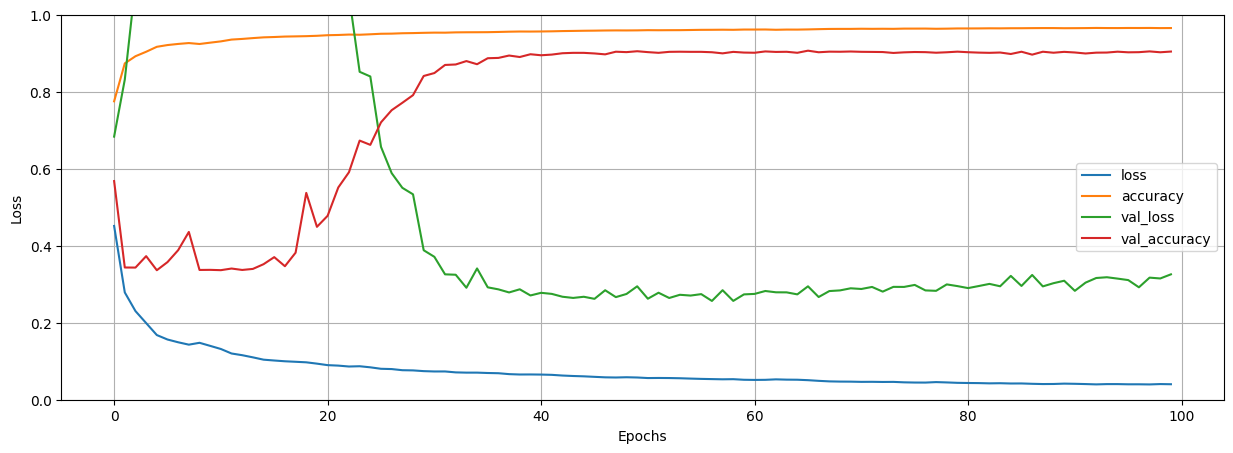

In [49]:
pd.DataFrame(history.history).plot(figsize=(15,5))
plt.ylim([0.0,1.0])
plt.xlabel("Epochs")

plt.ylabel("Loss")
plt.grid()
plt.show()

The difference in the **Training and Validation Loss** is **not high**, this is a **good sign**.

# **Model Predictions**

Let's have a closer look at the model predictions,

1/1 [==============================] - 1s 531ms/step


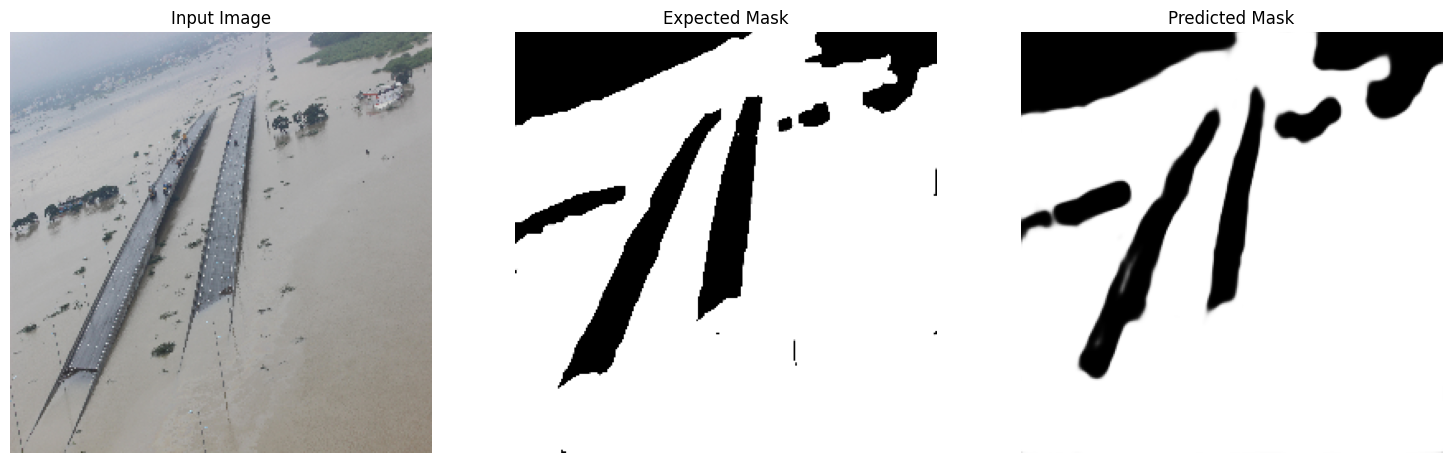

1/1 [==============================] - 0s 19ms/step


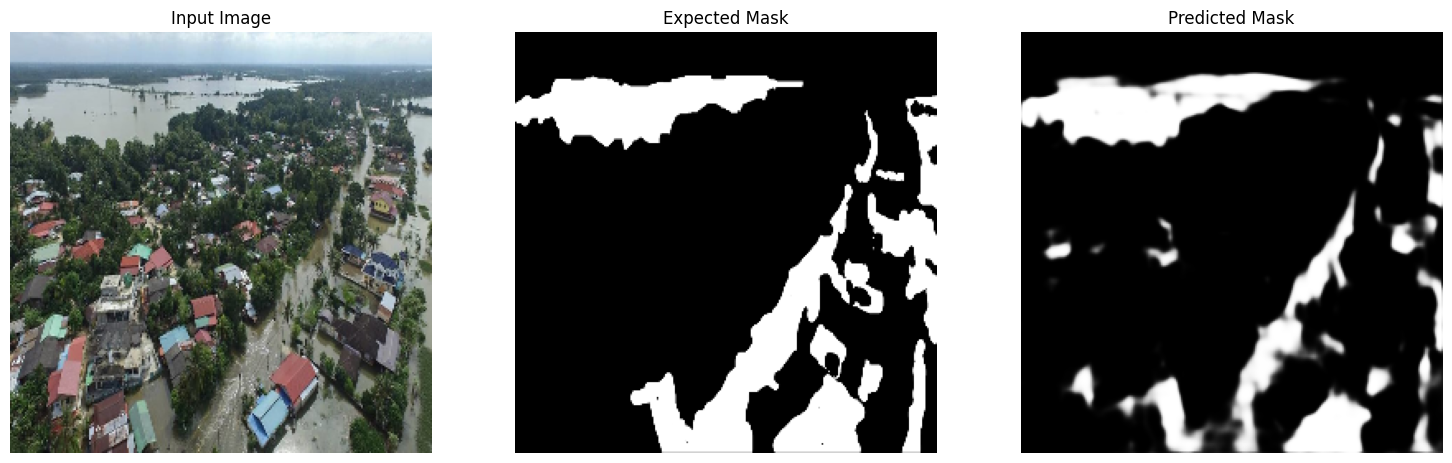

1/1 [==============================] - 0s 20ms/step


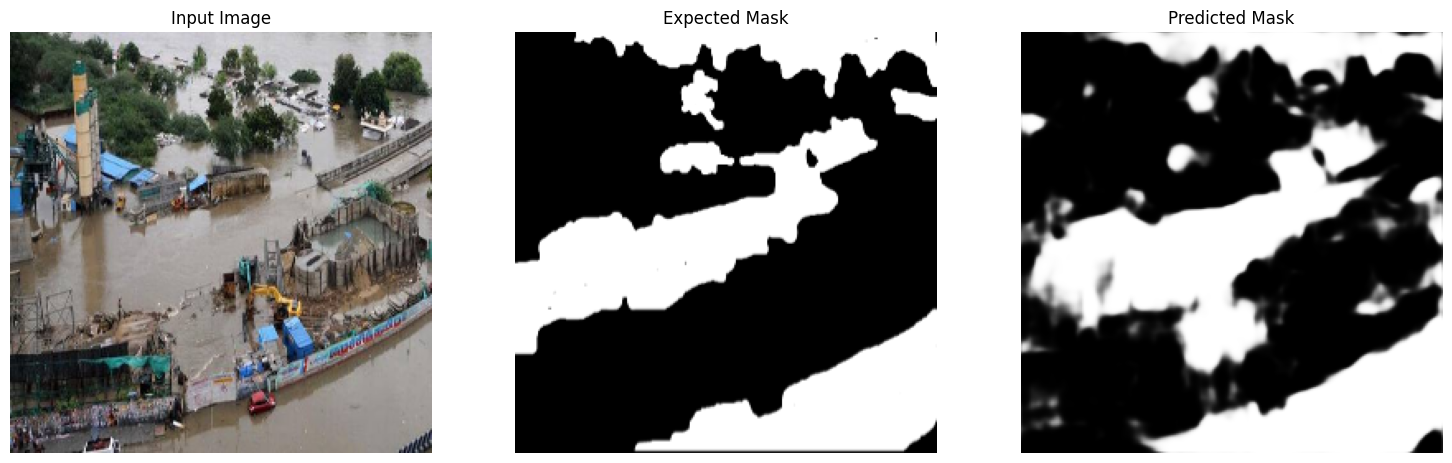

In [50]:
for i in range(3):
    show_model_preds(test_images, test_masks, model=DeepLabV3, SIZE=(25,8))

# Evaluation

In [52]:
import cv2

# --- Paths ---
image_dir = r"D:\WORK\Python\USTH\deep_learning\evaluate\val\images"
mask_dir = r"D:\WORK\Python\USTH\deep_learning\evaluate\val\labels"
model_path = r"D:\WORK\Python\USTH\deep_learning\models\deeplabv3_segmentation_v5.h5"

# --- Custom ConvBlock (matches DeepLabV3) ---
class ConvBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, dilation_rate=1, **kwargs):
        super().__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(filters, kernel_size, padding='same', 
                                           dilation_rate=dilation_rate, use_bias=False)
        self.bn = tf.keras.layers.BatchNormalization()
        self.act = tf.keras.layers.ReLU()

    def call(self, inputs, training=False):
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        return self.act(x)

# --- Custom ASPP Image Pool (matches DeepLabV3) ---
class ASPPImagePool(tf.keras.layers.Layer):
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.expand_dims = tf.keras.layers.Lambda(lambda x: tf.expand_dims(tf.expand_dims(x, 1), 1))
        self.conv = tf.keras.layers.Conv2D(filters, 1, padding='same', use_bias=False)
        self.bn = tf.keras.layers.BatchNormalization()
        self.act = tf.keras.layers.ReLU()
        self.upsample = tf.keras.layers.Lambda(lambda x, size: tf.image.resize(x, size, method='bilinear'))

    def call(self, inputs, training=False):
        size = tf.shape(inputs)[1:3]
        x = self.global_pool(inputs)
        x = self.expand_dims(x)
        x = self.conv(x)
        x = self.bn(x, training=training)
        x = self.act(x)
        x = self.upsample(x, size)
        return x

# --- Load model with custom layers ---
custom_objects = {
    'ConvBlock': ConvBlock,
    'ASPP-ImagePool-CB': ASPPImagePool
}

model = tf.keras.models.load_model(model_path, compile=False, custom_objects=custom_objects)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- Load validation images and masks ---
def load_data(image_dir, mask_dir, target_size=(256, 256)):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_name, mask_name in tqdm(zip(image_files, mask_files), total=len(image_files), desc="Loading validation data"):
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        img = cv2.resize(img, target_size)
        mask = cv2.resize(mask, target_size)

        images.append(img / 255.0)
        masks.append(np.expand_dims(mask / 255.0, axis=-1))

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

val_images, val_masks = load_data(image_dir, mask_dir)

# --- Predict ---
preds = model.predict(val_images, batch_size=8)
preds = (preds > 0.5).astype(np.uint8)

# --- Compute mean IoU ---
def compute_miou(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / (union + 1e-8)

miou = compute_miou(val_masks, preds)
print(f"✅ Mean IoU (mIoU): {miou:.4f}")


Loading validation data: 100%|██████████| 63/63 [00:00<00:00, 102.32it/s]


8/8 [==============================] - 2s 165ms/step
✅ Mean IoU (mIoU): 0.7186


##  Other test

[INFO] Model loaded successfully.
[SAVED] D:\WORK\Python\USTH\deep_learning\outputs\HS601_combined.png


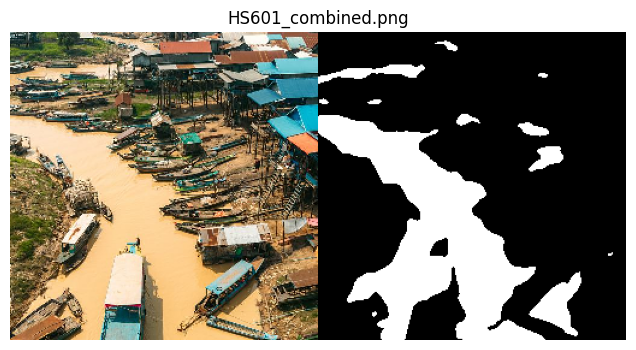

[SAVED] D:\WORK\Python\USTH\deep_learning\outputs\HS602_combined.png


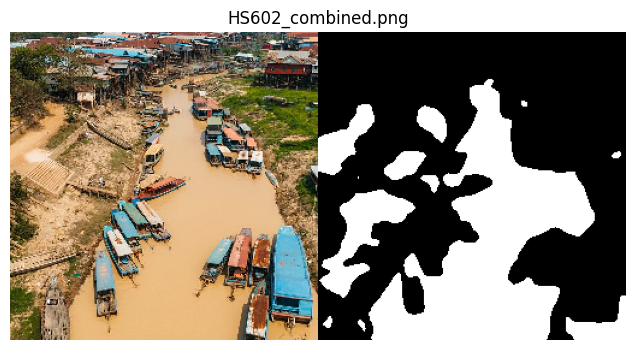

[SAVED] D:\WORK\Python\USTH\deep_learning\outputs\HS603_combined.png


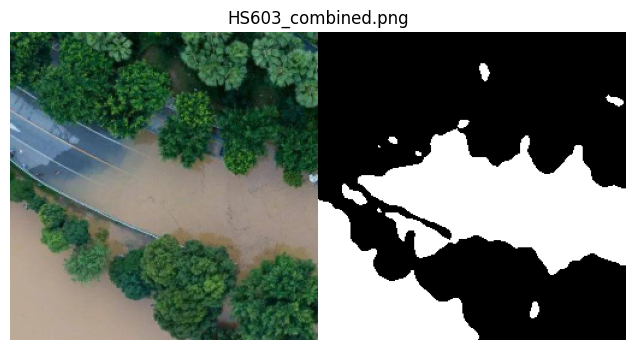

In [53]:

from PIL import Image

# --- Define ConvBlock (same as used during training) ---
class ConvBlock(Layer):
    def __init__(self, filters=256, kernel_size=3, dilation_rate=1, **kwargs):
        super().__init__(**kwargs)
        self.net = Sequential([
            Conv2D(filters, kernel_size=kernel_size, padding='same',
                   strides=1, dilation_rate=dilation_rate,
                   activation=None, use_bias=False),
            BatchNormalization(),
            ReLU()
        ])

    def call(self, inputs, **kwargs):
        return self.net(inputs, **kwargs)


# --- Configuration ---
MODEL_PATH = r"D:\WORK\Python\USTH\deep_learning\models\best_model.h5"
IMAGE_FOLDER = r"D:\WORK\Python\USTH\deep_learning\evaluate\val\images"
OUTPUT_FOLDER = r"D:\WORK\Python\USTH\deep_learning\outputs"
IMAGE_SIZE = (256, 256)
NUM_TEST_IMAGES = 3  # <-- Adjust number of test images here

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# --- Load model with custom_objects ---
model = load_model(
    MODEL_PATH,
    custom_objects={'ConvBlock': ConvBlock},
    compile=False
)
print("[INFO] Model loaded successfully.")


# --- Preprocessing function ---
def preprocess_image(path, target_size=IMAGE_SIZE):
    img = load_img(path, target_size=target_size)
    img = img_to_array(img) / 255.0
    return np.expand_dims(img, axis=0), img


# --- Predict, show and save combined output ---
image_paths = [os.path.join(IMAGE_FOLDER, f)
               for f in os.listdir(IMAGE_FOLDER)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:NUM_TEST_IMAGES]

for path in image_paths:
    img_input, img_display = preprocess_image(path)
    pred_mask = model.predict(img_input, verbose=0)[0]
    pred_mask = np.squeeze(pred_mask)
    pred_mask = (pred_mask > 0.5).astype(np.float32)

    # --- Convert arrays for saving ---
    img_display_uint8 = (img_display * 255).astype(np.uint8)
    pred_mask_color = np.stack([pred_mask * 255] * 3, axis=-1).astype(np.uint8)

    # --- Combine original and predicted mask horizontally ---
    combined = np.concatenate([img_display_uint8, pred_mask_color], axis=1)

    # --- Save combined output ---
    output_name = os.path.splitext(os.path.basename(path))[0] + "_combined.png"
    output_path = os.path.join(OUTPUT_FOLDER, output_name)
    Image.fromarray(combined).save(output_path)
    print(f"[SAVED] {output_path}")

    # --- Show preview ---
    plt.figure(figsize=(8, 4))
    plt.imshow(combined)
    plt.title(os.path.basename(output_name))
    plt.axis("off")
    plt.show()
